In [2]:
%autoreload 2

In [10]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 13})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\4106574887.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__GET RELEVANT BEHAVIOR DATA__

In [3]:
path = "C://Data//Imaging//260425_overlap//fish3//"
fish = Gafftopsail(path, filelist = ['stimulus', 'eye', 'tail', 'processed_eye', 'processed_tail'])
#stimulus_df =Coelacanth(f + '//', filelist = ['stimulus']).stimulus_df
fish.stimulus_df.loc[:, "stim_name"] = [str(s) for s in fish.stimulus_df.stim_name]

#for overlap fishes
omr_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
dot_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
overlap_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
stimlists = [omr_stim, dot_stim, overlap_stim]
#for dot fish

bouts are classified
eye classified


__HUNTING OR NOT__

In [29]:
def classify_saccade(fish):
    saccade_types = []
    for n, row in fish.saccade_df.iterrows():
        if ((row.e0_change <= 0)  and (row.e1_change >= 0)):
            saccade_types.append('H')
        elif row.e_conj_change < 0:
            saccade_types.append('L')
        else:
            saccade_types.append('R')
    fish.saccade_df.loc[:, 'saccade_type'] = saccade_types
    fish.saccade_df.to_csv(fish.path + '//eye//eye_saccade_df_classified.csv')
    fig, ax = plt.subplots( 1, 1, )
    sns.scatterplot(x = fish.saccade_df.e_conv_change, y = fish.saccade_df.e_conj_change, hue = fish.saccade_df.saccade_type, ax = ax)
    plt.show()
    plt.close()



In [12]:
def find_saccading_bout(fish):
    #for each bout, asslign the closest saccade and
    max_diff_s = 5
    all_diffs = []
    all_convs = []
    all_conjs = []
    all_saccade_types = []
    bout_start_s = [float(i[0]) for i in fish.bout_df.cont_tuples_realtime_s]
    saccade_start_s = [float(i[0]) for i in fish.saccade_df.cont_tuples_realtime_s]
    diffs = [np.subtract(bs, saccade_start_s) for bs in bout_start_s]#positive: saccade -> bout, negative: bout-> saccade
    nearest_saccade_s = [diff[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_s = [i if np.abs(i) <= max_diff_s else np.nan for i in nearest_saccade_s]
    nearest_saccade_type = [fish.saccade_df['saccade_type'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_conv = [fish.saccade_df['e_conv_change'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    nearest_saccade_conj = [fish.saccade_df['e_conj_change'].iloc[np.argmin(np.abs(diff))] for diff in diffs]
    all_saccade_types.extend(nearest_saccade_type)
    all_diffs.extend(nearest_saccade_s)
    all_convs.extend(nearest_saccade_conv)
    all_conjs.extend(nearest_saccade_conj)
    fish.bout_df.loc[:, 'nearest_saccade_s'] = all_diffs
    fish.bout_df.loc[:, 'nearest_saccade_conv'] = all_convs
    fish.bout_df.loc[:, 'nearest_saccade_conj'] = all_conjs
    fish.bout_df.loc[:, 'nearest_saccade_type'] = all_saccade_types
#find_saccading_bout(fish)

In [13]:
def classify_all(fish):
    #if eye convergence: hunting
    hunting_eye = []
    hunting_tail = []
    okr_eye = []
    omr_tail = []
    some_eye = []
    some_tail = []
    bout_start_s = [float(i[0]) for i in fish.bout_df.cont_tuples_realtime_s]
    saccade_start_s = [float(i[0]) for i in fish.saccade_df.cont_tuples_realtime_s]
    for n, stimrow in fish.stimulus_df.iterrows():
        stationary_time = stimrow.stationary_time
        duration =stimrow.duration
        if type(stationary_time) == list:
            dot_stationary_time = stationary_time[0]
            grating_stationary_time = stationary_time[1]
        elif 'dot' in stimrow.stim_name:
            dot_stationary_time = stationary_time
            grating_stationary_time = duration
        elif 'dot' not in stimrow.stim_name:
            dot_stationary_time = stationary_time
            grating_stationary_time = duration
        #isolate bout/saccade during the stimulus
        stim_saccade = np.argwhere((saccade_start_s >= np.float64(stimrow.real_starttime_s + min(grating_stationary_time, dot_stationary_time))) & (saccade_start_s <= np.float64(stimrow.real_starttime_s + duration))).flatten()
        stim_bout = np.argwhere((bout_start_s >= np.float64(stimrow.real_starttime_s + min(grating_stationary_time, dot_stationary_time))) & (bout_start_s <= np.float64(stimrow.real_starttime_s + duration))).flatten()
        if len(stim_saccade) > 0:
            stim_saccade = list(fish.saccade_df.iloc[stim_saccade].saccade_type)
            some_eye.append(True)
            #determining hunting
            if 'H' in stim_saccade:
                hunting_eye.append(True)
            else:
                hunting_eye.append(False)
            #determining OKR: if any good saccade
            okr = False
            if 'left' in str(stimrow.stim_name):
                if 'R' in stim_saccade:
                    okr = True
            elif 'right' in str(stimrow.stim_name):
                if 'L' in stim_saccade:
                    okr = True
            okr_eye.append(okr)
        else:
            hunting_eye.append(False)
            okr_eye.append(False)
            some_eye.append(False)

        if len(stim_bout) > 0:
            stim_bout = list(fish.bout_df.iloc[stim_bout].bout_type)
            some_tail.append(True)
            #determining hunting
            if 'H' in stim_bout:
                hunting_tail.append(True)
            else:
                hunting_tail.append(False)
            #determining OMR: if any good saccade
            omr = False
            if 'left' in str(stimrow.stim_name):
                if 'L' in stim_bout:
                    omr = True
            elif 'right' in str(stimrow.stim_name):
                if 'R' in stim_bout:
                    omr = True
            elif 'forward' in str(stimrow.stim_name) or 'backward' in str(stimrow.stim_name):
                omr = True
            omr_tail.append(omr)
        else:
            hunting_tail.append(False)
            omr_tail.append(False)
            some_tail.append(False)
    fish.stimulus_df.loc[:, 'hunting_eye'] = hunting_eye
    fish.stimulus_df.loc[:, 'hunting_tail'] = hunting_tail
    fish.stimulus_df.loc[:, 'okr_eye'] = okr_eye
    fish.stimulus_df.loc[:, 'omr_tail'] = omr_tail
    fish.stimulus_df.loc[:, 'some_eye'] = some_eye
    fish.stimulus_df.loc[:, 'some_tail'] = some_tail
#classify_all(fish)

In [15]:
fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key = 'stimulus')

C:\Users\Zichen\AppData\Local\Temp\ipykernel_12608\3364995906.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key = 'stimulus')


bouts are classified
eye classified


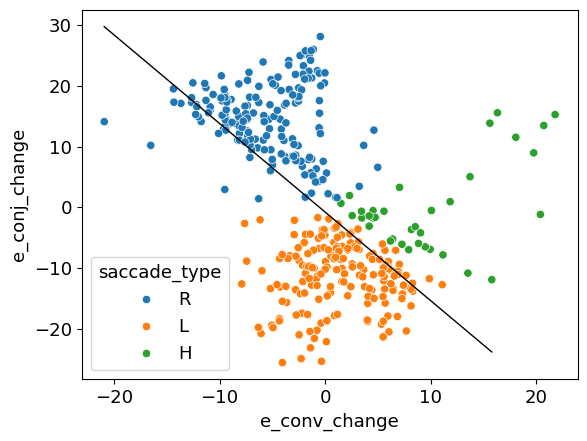

stim_name
dot_l                    5
dot_r                    2
forward                  2
['dot_l', 'forward']     2
['dot_r', 'backward']    2
left                     2
['dot_r', 'right']       2
['dot_r', 'left']        1
right                    1
['dot_l', 'right']       1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


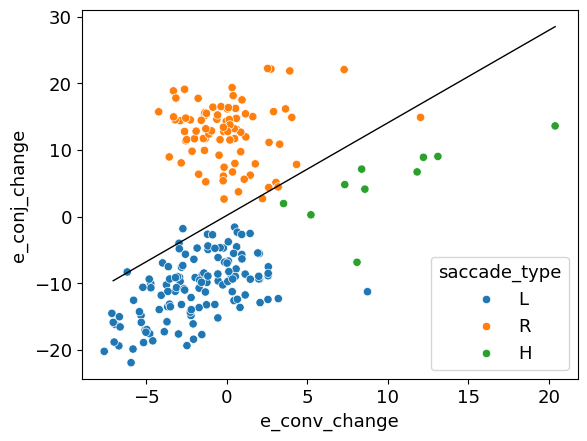

stim_name
['dot_r', 'left']        1
['dot_r', 'right']       1
backward                 1
['dot_l', 'backward']    1
dot_l                    1
right                    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


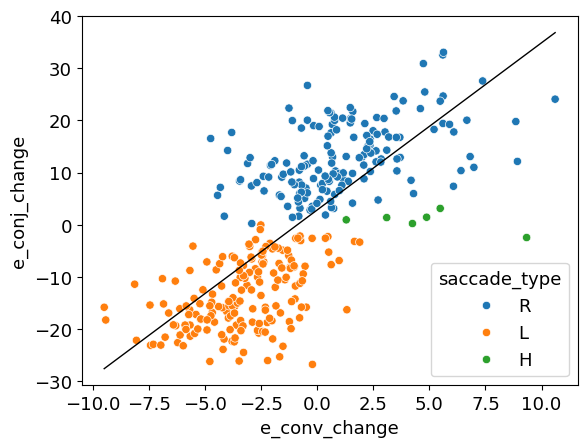

stim_name
left                 1
['dot_l', 'left']    1
right                1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


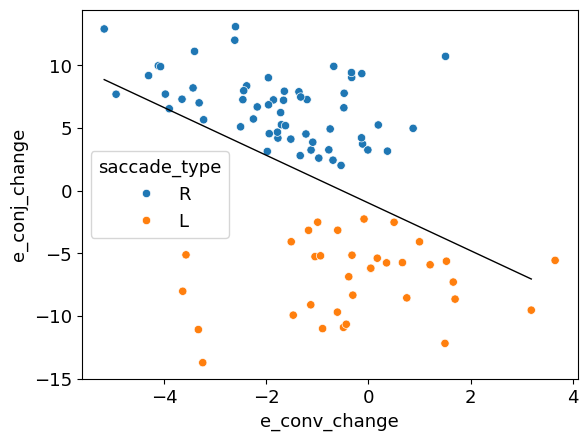

Series([], Name: count, dtype: int64)


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


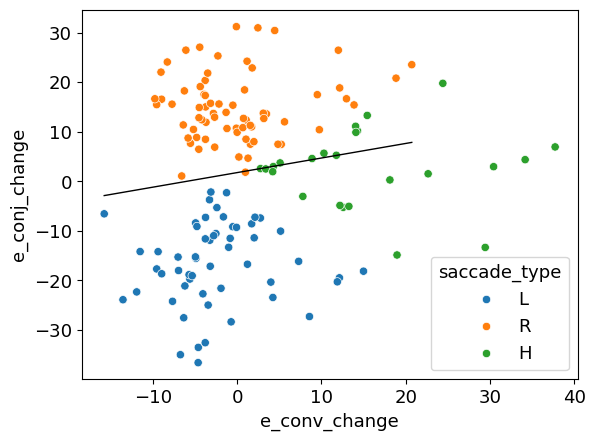

stim_name
dot_r                    3
dot_l                    3
['dot_r', 'left']        1
['dot_l', 'backward']    1
['dot_l', 'right']       1
['dot_r', 'backward']    1
['dot_l', 'forward']     1
left                     1
['dot_r', 'forward']     1
['dot_r', 'right']       1
['dot_l', 'left']        1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


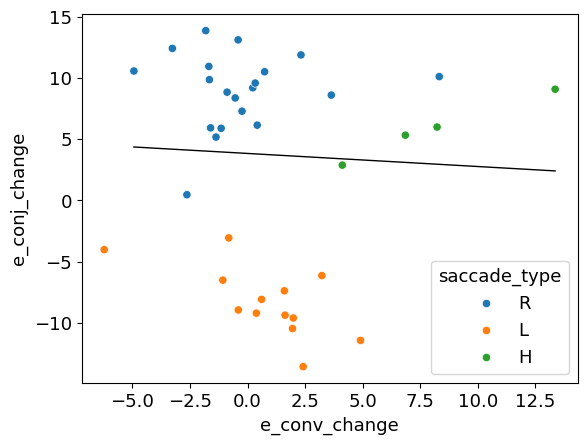

Series([], Name: count, dtype: int64)


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


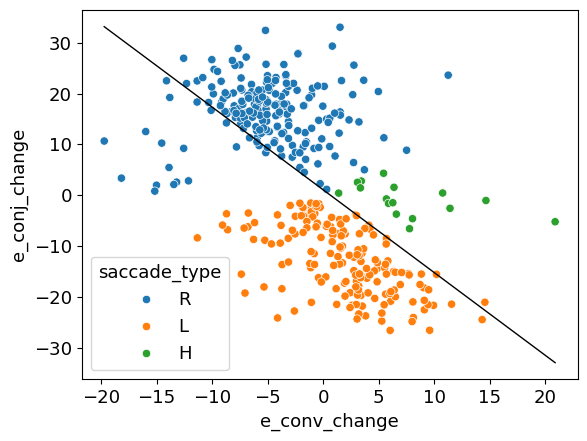

stim_name
['dot_l', 'left']     2
left                  1
backward              1
['dot_l', 'right']    1
dot_l                 1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


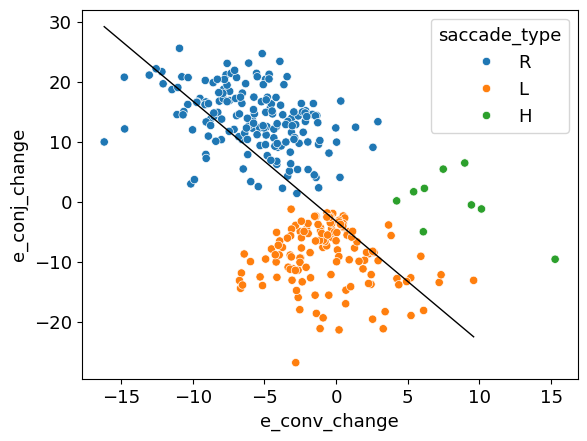

stim_name
dot_r                   2
dot_l                   2
['dot_l', 'right']      1
['dot_r', 'left']       1
['dot_l', 'forward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


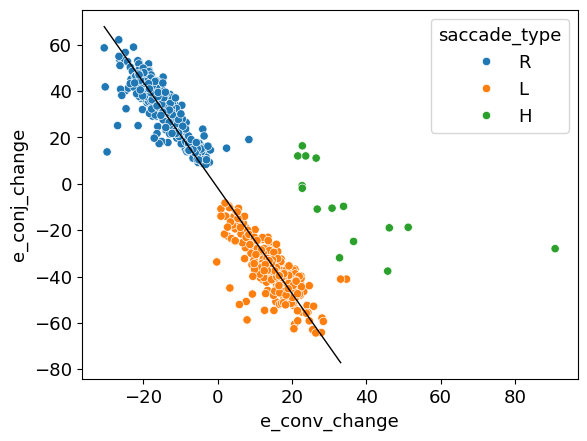

stim_name
dot_l                    4
dot_r                    3
['dot_l', 'backward']    2
['dot_l', 'right']       2
['dot_r', 'left']        1
['dot_l', 'left']        1
['dot_r', 'right']       1
['dot_l', 'forward']     1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


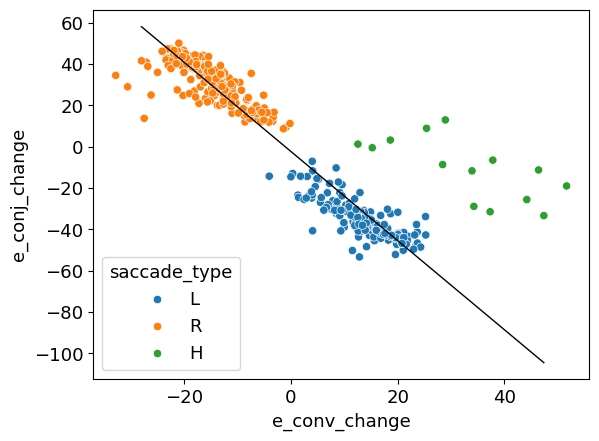

stim_name
['dot_l', 'backward']    2
dot_r                    2
['dot_l', 'right']       2
['dot_r', 'right']       2
dot_l                    2
['dot_l', 'left']        1
['dot_r', 'backward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


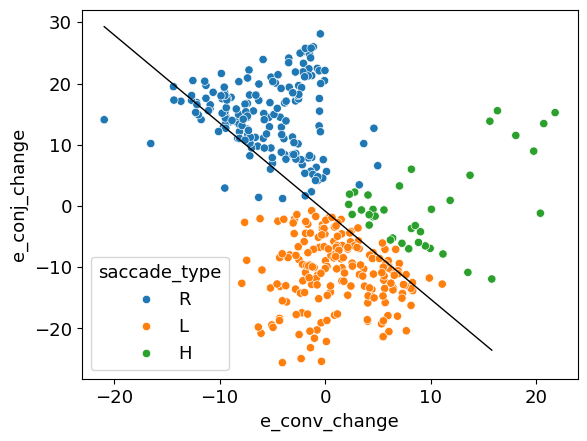

stim_name
dot_l                    5
dot_r                    2
['dot_l', 'right']       2
['dot_r', 'right']       2
['dot_l', 'forward']     2
['dot_r', 'backward']    2
left                     2
['dot_r', 'left']        1
['dot_l', 'left']        1
right                    1
forward                  1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


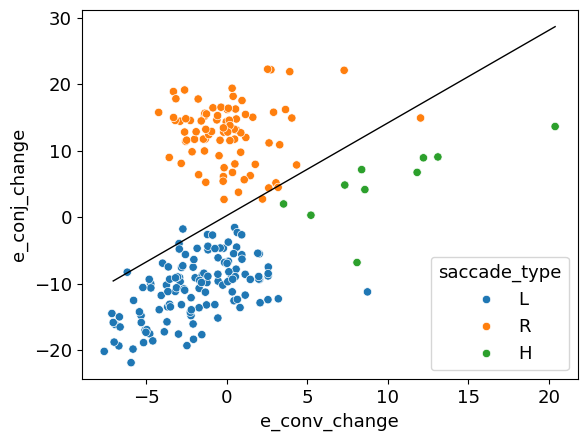

stim_name
['dot_r', 'left']        1
['dot_r', 'right']       1
backward                 1
['dot_l', 'backward']    1
dot_l                    1
right                    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


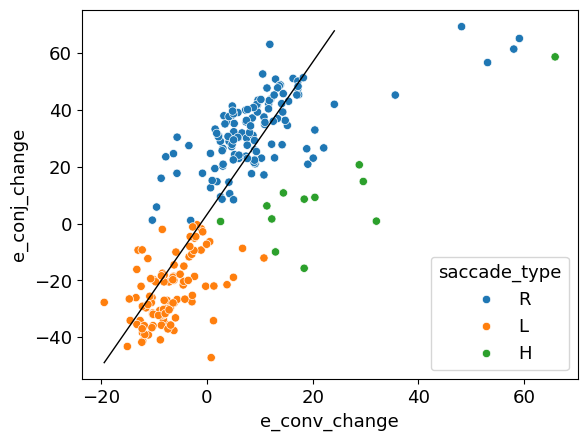

stim_name
dot_r                    4
['dot_r', 'forward']     3
['dot_l', 'backward']    2
['dot_r', 'backward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


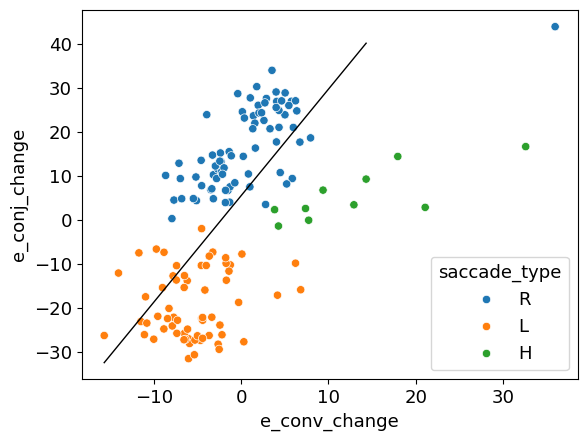

stim_name
['dot_l', 'right']       3
['dot_l', 'backward']    2
dot_r                    1
['dot_r', 'backward']    1
backward                 1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


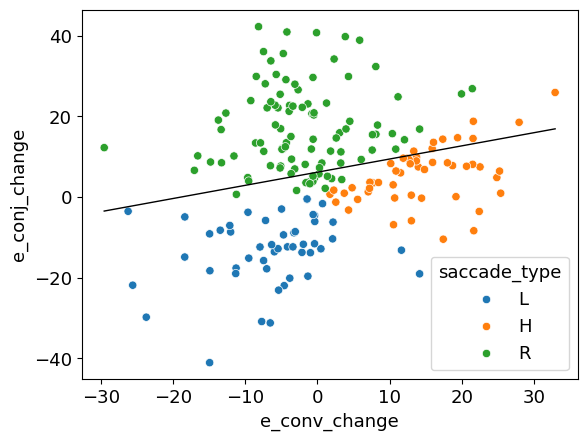

stim_name
dot_r                    5
['dot_l', 'backward']    3
dot_l                    2
['dot_l', 'right']       2
['dot_r', 'backward']    2
['dot_r', 'forward']     1
['dot_l', 'forward']     1
['dot_r', 'left']        1
right                    1
backward                 1
forward                  1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


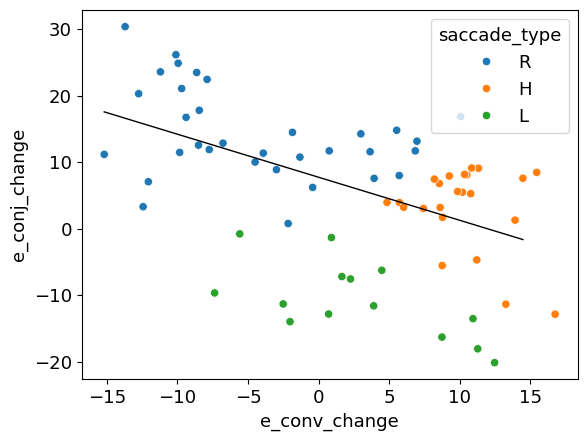

stim_name
dot_l                    5
['dot_r', 'right']       1
backward                 1
left                     1
['dot_l', 'forward']     1
['dot_l', 'backward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


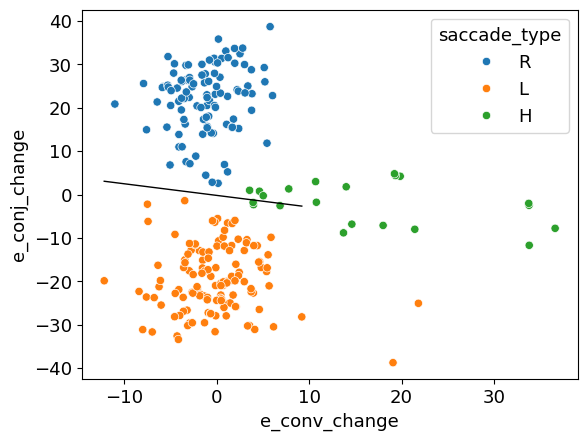

stim_name
dot_l                    9
dot_r                    4
['dot_l', 'right']       2
['dot_r', 'left']        1
['dot_r', 'right']       1
['dot_r', 'backward']    1
['dot_l', 'forward']     1
['dot_l', 'backward']    1
forward                  1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


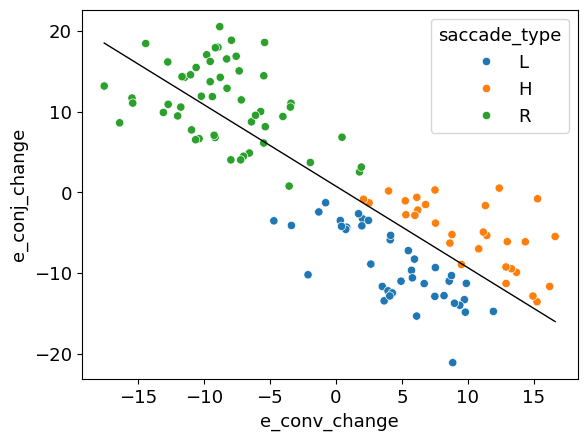

stim_name
dot_l                    3
left                     3
['dot_r', 'backward']    2
forward                  1
backward                 1
dot_r                    1
['dot_r', 'left']        1
right                    1
['dot_l', 'backward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


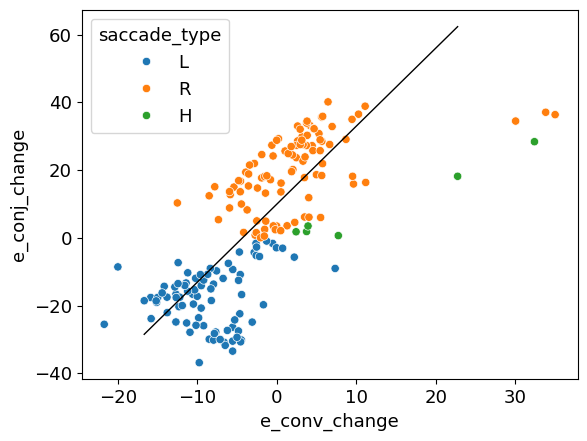

stim_name
forward              2
left                 1
['dot_l', 'left']    1
dot_r                1
dot_l                1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


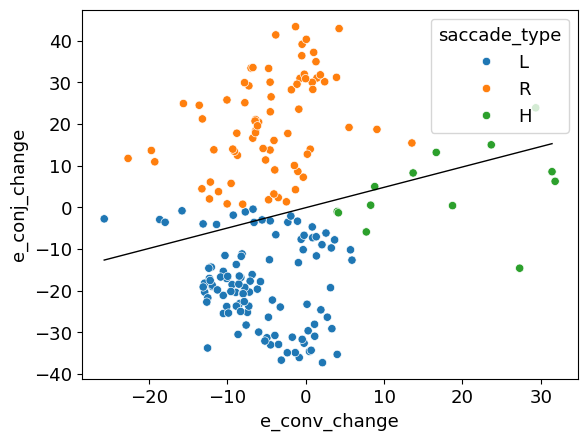

stim_name
right                    3
dot_r                    3
['dot_l', 'backward']    1
['dot_l', 'left']        1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


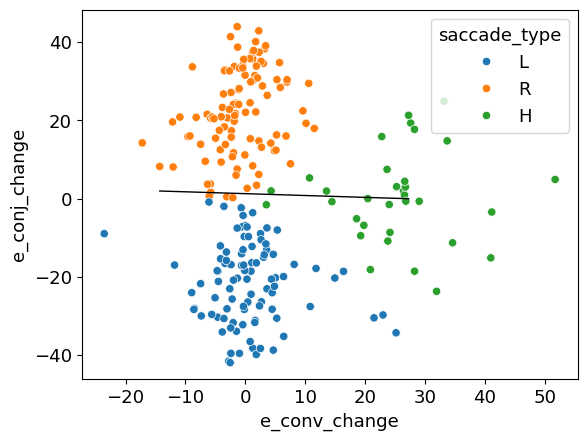

stim_name
dot_l                    7
dot_r                    6
['dot_l', 'right']       4
['dot_r', 'left']        3
['dot_l', 'backward']    2
['dot_r', 'backward']    2
['dot_l', 'left']        1
backward                 1
['dot_l', 'forward']     1
right                    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


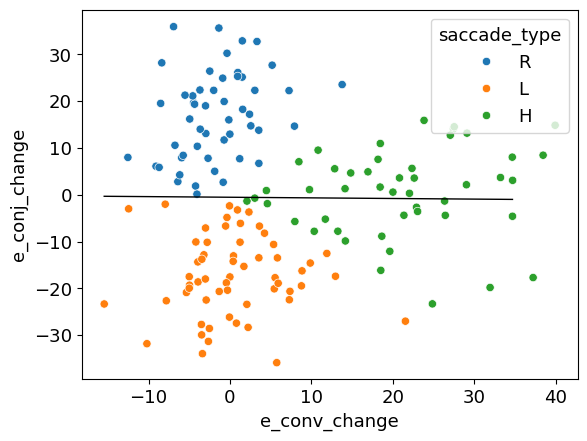

stim_name
dot_l                    8
dot_r                    5
['dot_l', 'right']       4
['dot_r', 'left']        3
left                     2
backward                 2
['dot_l', 'backward']    1
['dot_r', 'backward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


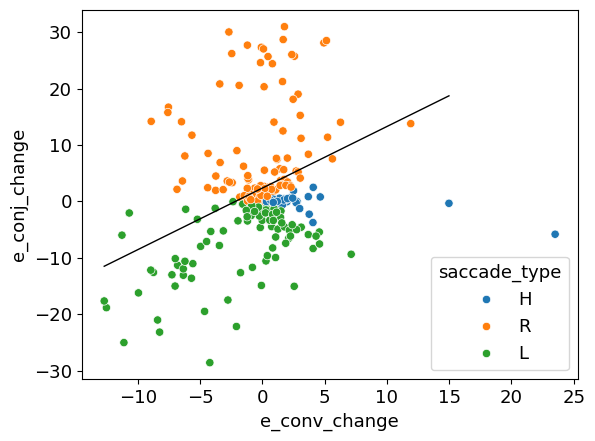

stim_name
left                     4
['dot_r', 'backward']    3
['dot_l', 'right']       3
right                    3
forward                  2
['dot_r', 'forward']     2
['dot_l', 'forward']     2
dot_r                    1
backward                 1
['dot_l', 'left']        1
['dot_r', 'right']       1
['dot_l', 'backward']    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


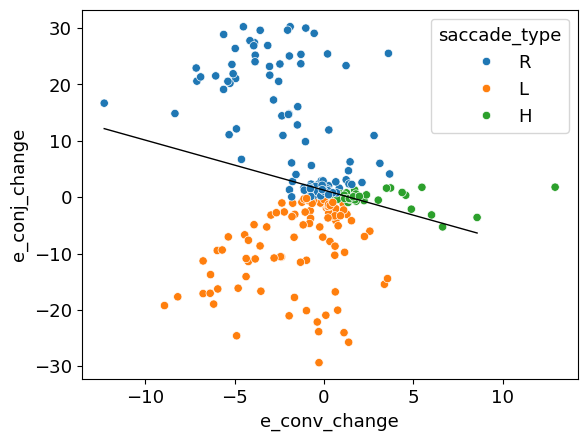

stim_name
right                   6
['dot_l', 'right']      3
['dot_r', 'right']      2
left                    2
['dot_l', 'forward']    1
['dot_l', 'left']       1
dot_l                   1
forward                 1
backward                1
['dot_r', 'left']       1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


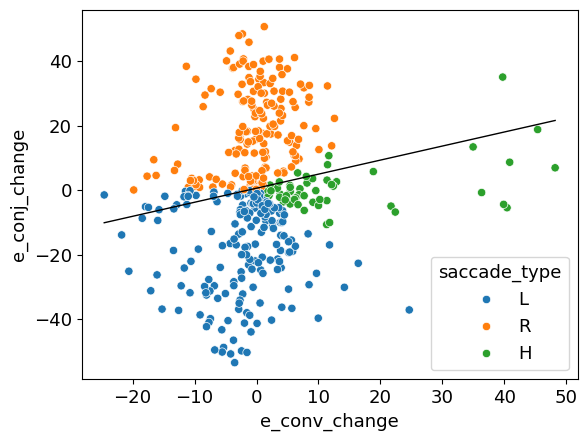

stim_name
forward                  3
['dot_r', 'backward']    3
['dot_l', 'left']        2
backward                 2
['dot_r', 'left']        2
left                     1
['dot_l', 'forward']     1
dot_r                    1
['dot_r', 'right']       1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


bouts are classified
eye classified


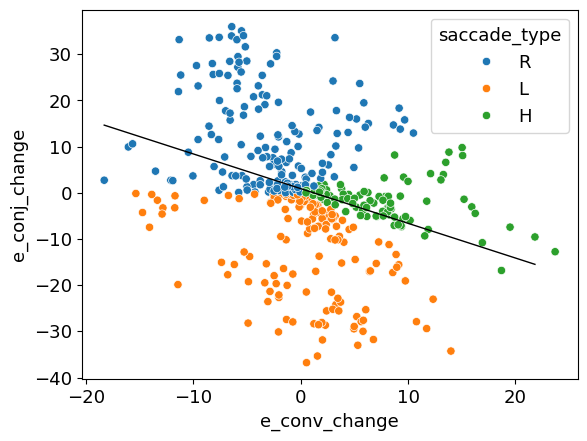

stim_name
right                    8
forward                  7
left                     5
['dot_r', 'forward']     5
['dot_l', 'right']       5
backward                 5
['dot_r', 'right']       4
['dot_l', 'forward']     4
['dot_l', 'left']        3
dot_l                    2
['dot_r', 'left']        2
['dot_l', 'backward']    1
['dot_r', 'backward']    1
dot_r                    1
Name: count, dtype: int64


C:\Users\Zichen\AppData\Local\Temp\ipykernel_30728\1527942617.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['stim_name', 'angle', 'velocity', 'stim_type', 'stationary_time',
       'texture', 'circle_center', 'circle_radius', 'angular_velocity'],
      dtype='object')]

  fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')


In [28]:
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]
for path in paths:
    fish = Gafftopsail(path + '//', filelist=['stimulus', 'eye', 'tail', 'processed_eye', 'processed_tail'])
    fish.stimulus_df.loc[:, "stim_name"] = [str(s) for s in fish.stimulus_df.stim_name]

    #for overlap fishes
    omr_stim = [i for i in fish.stimulus_df.stim_name.unique() if
                ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
    dot_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
    overlap_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
    stimlists = [omr_stim, dot_stim, overlap_stim]

    classify_saccade(fish)
    find_saccading_bout(fish)
    classify_all(fish)
    print(fish.stimulus_df[fish.stimulus_df.hunting_eye].stim_name.value_counts())
    plt.close()
    fish.stimulus_df.to_hdf(fish.path + '//stimulus_df.hdf', key='stimulus')

In [17]:
#check results
saccades = []
bouts = []
for path in paths:
    eye = pd.read_csv(path + '//eye//eye_saccade_df_classified.csv')
    tail = pd.read_csv(path + '//tail//tail_bout_df_classified.csv')
    eye.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
    tail.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]

    saccades.append(eye)
    bouts.append(tail)
saccades = pd.concat(saccades, axis = 0, ignore_index = True)
bouts = pd.concat(bouts, axis = 0, ignore_index = True)

In [18]:
saccades[saccades.saccade_type == 'H'].eye_realstimuli.value_counts()

eye_realstimuli
stationary               413
pause                    110
dot_l                     92
dot_r                     73
right                     64
forward                   63
backward                  43
left                      41
['dot_l', 'right']        41
['dot_l', 'backward']     33
['dot_r', 'left']         28
['dot_r', 'backward']     28
['dot_r', 'right']        25
['dot_l', 'forward']      24
['dot_l', 'left']         21
['dot_r', 'forward']      12
Name: count, dtype: int64

In [19]:
bouts[bouts.bout_type == 'dot'].tail_realstimuli.value_counts()

Series([], Name: count, dtype: int64)

In [20]:
bouts[bouts.bout_type == 'R'].tail_realstimuli.value_counts()

tail_realstimuli
stationary               937
right                    612
forward                  478
pause                    437
['dot_l', 'right']       224
['dot_r', 'right']       202
left                     160
['dot_r', 'forward']     129
['dot_l', 'forward']     128
backward                 114
['dot_r', 'left']         46
dot_r                     38
['dot_r', 'backward']     32
['dot_l', 'left']         31
['dot_l', 'backward']     30
dot_l                     30
Name: count, dtype: int64